- Load the dataset

In [102]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as st

In [7]:
data = pd.read_csv("loan_applications.csv")

- Part B - Practical (Python Programming)

- Step 1: Central Tendency & Dispersion
    - Find mean, median, and mode of Income.
    - Calculate range, variance, and standard deviation of Loan _Amount.

In [12]:
# find the mean, median and mode of Income column
income_mean = data["Income"].mean()
income_median = data["Income"].median()
income_mode = data["Income"].mode()[0]

print(f"Mean of Income is {income_mean}")
print(f"Median of Income is {income_median}")
print(f"Mode of Income is {income_mode}")

Mean of Income is 85020.7206
Median of Income is 85929.0
Mode of Income is 21620


In [16]:
# Calculate range, variance, and standard deviation of Loan_Amount.
loan_amount_range = max(data["Loan_Amount"]) - min(data["Loan_Amount"])
loan_amount_variance = data["Loan_Amount"].var()
loan_amount_std = data["Loan_Amount"].std()

print(f"Range of Loan Amount is {loan_amount_range}")
print(f"Variance of Loan Amount is {loan_amount_variance}")
print(f"Standard Deviation of Loan Amount is {loan_amount_std}")

Range of Loan Amount is 44995
Variance of Loan Amount is 170700199.59324968
Standard Deviation of Loan Amount is 13065.228646803303


- Step 2: Probability & Events
    - Compute probability of loan default.
    - Create a contingency table between Default_Status and Credit_Score (categorized into
ranges).
    - Compute conditional probability: P(Default | Credit_Score < 600).

In [166]:
# Compute probability of loan default
prob_of_loan_default = round((data["Default_Status"][data["Default_Status"]=="Yes"].count()/data["Default_Status"].count())*100,3)
print(f"P(Default) = {prob_of_loan_default} %")

# Create a contingency table between Default_Status and Credit_Score (categorized into ranges).
bins = [0, 500, 600, 700, 850] 
labels = ['Poor', 'Fair', 'Good', 'Excellent']  
data['Credit_Score_Category'] = pd.cut(data['Credit_Score'], bins=bins, labels=labels, right=True)
contingency_table = pd.crosstab(data['Default_Status'], data['Credit_Score_Category'])
print(f"Contingency Table:{contingency_table}")

# Compute conditional probability: P(Default | Credit_Score < 600)
prob_of_defualt_or_credit_score_below_600 = round(data["Default_Status"][(data["Default_Status"]=="Yes") | (data["Credit_Score"]<600)].count()/data["Default_Status"].count(),3)*100
print(f"P(Default | Credit_Score < 600) = {prob_of_defualt_or_credit_score_below_600} %")

P(Default) = 50.86 %
Contingency Table:Credit_Score_Category  Poor  Fair  Good  Excellent
Default_Status                                    
No                      926   436   461        634
Yes                     883   460   477        723
P(Default | Credit_Score < 600) = 78.0 %


- Step 3: Distributions & Visualization
    - Plot a Histogram of Credit_Score with a Gaussian curve.
    - Check Skewness and Kurtosis of Loan_Amount.
    - Draw a Q-Q Plot for Income.

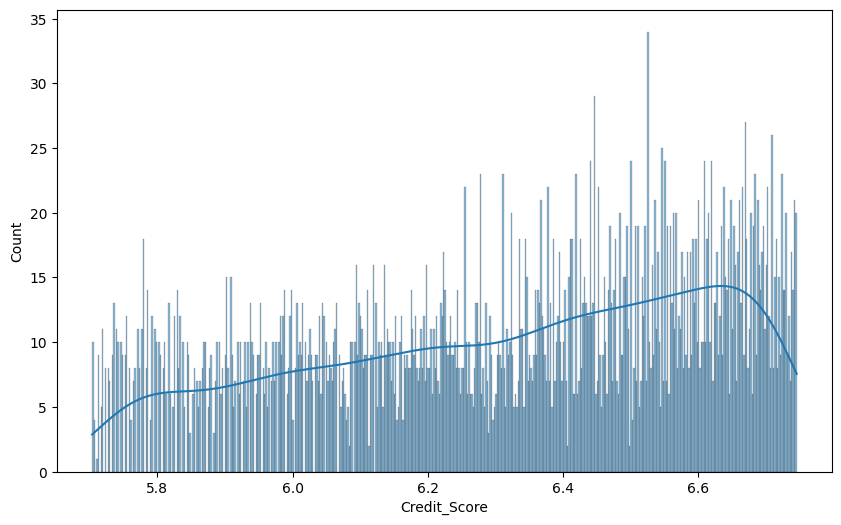

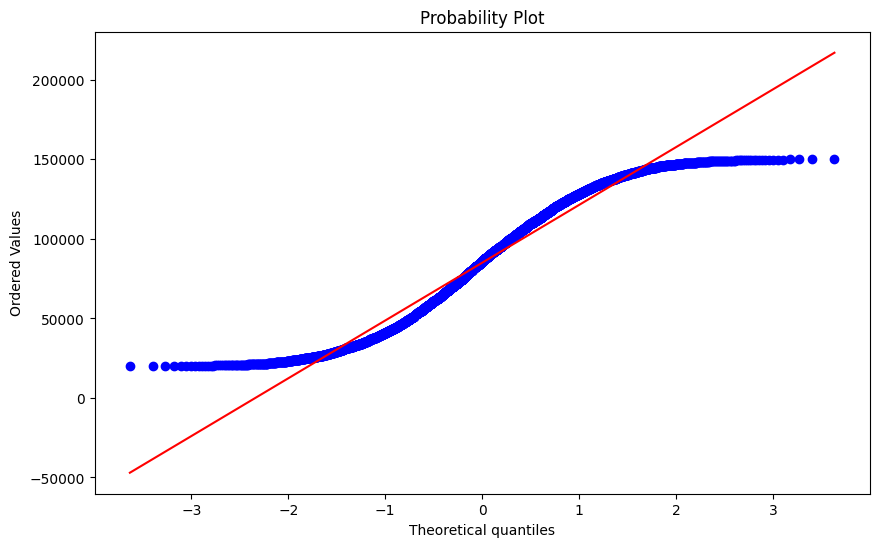

Skewness value of loan amount is 0.01747529207495258
Kurtosis value of loan amount is -1.2128973889293146


In [106]:
# Plot a Histogram of Credit_Score with a Gaussian curve.
plt.figure(figsize=(10,6))
sns.histplot(np.log(data["Credit_Score"]),kde=True,bins=500)
plt.show()

# Draw a Q-Q Plot for Income
plt.figure(figsize=(10,6))
st.probplot(data["Income"],dist="norm",plot=plt)
plt.show()

# Check Skewness and Kurtosis of Loan_Amount
skewness_of_loan_amount = data["Loan_Amount"].skew()
kurtosis_of_loan_amount = data["Loan_Amount"].kurtosis()
print(f"Skewness value of loan amount is {skewness_of_loan_amount}")
print(f"Kurtosis value of loan amount is {kurtosis_of_loan_amount}")

- Step 4: Linear Algebra Application
    - Take the first 5 customers' [Income, Loan_Amount] as vectors.
    - Perform dot product between two customer vectors.
    - Find Norm 2 of a customer's financial vector.
    - Calculate the angle between two customers' vectors.

In [154]:
# Take the first 5 customers's [Income, Loan_Amount] as vectors
financial_vector = np.array([data.iloc[i][["Income","Loan_Amount"]].values for i in range(5)])

# perform dot product between two customer vectors
customer_1 = np.array(data.iloc[0][["Income","Loan_Amount","Credit_Score","Loan_Term"]])
customer_2 = np.array(data.iloc[1][["Income","Loan_Amount","Credit_Score","Loan_Term"]])

dot_product = np.dot(customer_1, customer_2)
print(f"Dot Product of two customers vectors is {dot_product}")

# Find Norm 2 of a customer's financial vector
euclidean_distance_of_finance_vector = np.linalg.norm(financial_vector)
print(f"Euclidean distance is {euclidean_distance_of_finance_vector}")

# Calculate the angle between two customers vectors.
cust_1 = np.array(data.iloc[0][["Income","Loan_Amount"]])
cust_2 = np.array(data.iloc[1][["Income","Loan_Amount"]])
dot_product_of_two_customers = np.dot(cust_1, cust_2)

distance_1 = np.linalg.norm(financial_vector[0])
distance_2 = np.linalg.norm(financial_vector[1])
multiplied_distance = distance_1 * distance_2 

# give degree in radians
angle_radians = np.arccos(dot_product / multiplied_distance)

# convert radians into degree
angle_degree = np.degrees(angle_radians)

print(f"Angle between two customer vectors is {angle_degree}")

Dot Product of two customers vectors is 9632955613
Euclidean distance is 240439.87192851354
Angle between two customer vectors is 3.922986051946687
